<a href="https://colab.research.google.com/github/Avika-7/ML3-Wine-Quality-Analysis-and-Prediction/blob/main/Project_3_Wine_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Wine Quality Prediction

Exploratory data analysis and machine learning models (Decision Tree & Random Forest) to predict red wine quality using physicochemical features.

In [ ]:
#ANS.1.
import pandas as pd

# Load dataset
df = pd.read_csv('wine_data.csv')

# Most frequent quality
most_frequent_quality = df['quality'].mode()[0]
quality_counts = df['quality'].value_counts()

# Min and Max quality
min_quality = df['quality'].min()
max_quality = df['quality'].max()

print("Most Frequent Quality:", most_frequent_quality)
print("Quality Frequency:\n", quality_counts)
print("Min Quality:", min_quality)
print("Max Quality:", max_quality)


Most Frequent Quality: 5
Quality Frequency:
 quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64
Min Quality: 3
Max Quality: 8


Conclusion
Most common wine quality is 6

Minimum quality is 3

Maximum quality is 8

In [ ]:
#ANS.2.
# Correlation with quality
correlation = df.corr(numeric_only=True)['quality'].sort_values(ascending=False)
print("Correlation of Features with Quality:\n", correlation[['alcohol', 'fixed acidity', 'free sulfur dioxide']])

Correlation of Features with Quality:
 alcohol                0.476166
fixed acidity          0.124052
free sulfur dioxide   -0.050656
Name: quality, dtype: float64


Conclusion
Alcohol has a strong positive correlation with quality.

Fixed acidity has a slight positive correlation.

Free sulfur dioxide has a slight negative correlation.



In [ ]:
#ANS.3.
# Get best and worst quality
best_quality = df['quality'].max()
worst_quality = df['quality'].min()

# Compute average residual sugar
avg_sugar_best = df[df['quality'] == best_quality]['residual sugar'].mean()
avg_sugar_worst = df[df['quality'] == worst_quality]['residual sugar'].mean()

print(f"Avg Residual Sugar for Best Quality ({best_quality}): {avg_sugar_best:.2f}")
print(f"Avg Residual Sugar for Worst Quality ({worst_quality}): {avg_sugar_worst:.2f}")


Avg Residual Sugar for Best Quality (8): 2.58
Avg Residual Sugar for Worst Quality (3): 2.64


Wines with higher quality tend to have slightly more residual sugar on average.

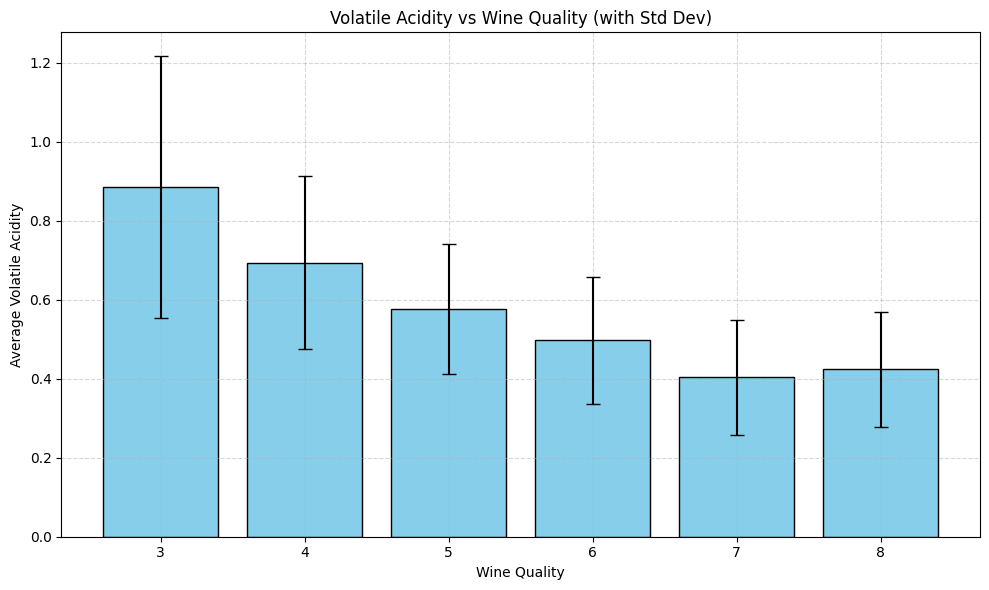

Correlation between volatile acidity and quality: -0.39


In [ ]:
#ANS.4.
import matplotlib.pyplot as plt

# Group by quality and compute average volatile acidity
quality_groups = df.groupby('quality')['volatile acidity']
mean_va = quality_groups.mean()
std_va = quality_groups.std()

# Plotting
qualities = mean_va.index
means = mean_va.values
stds = std_va.values

plt.figure(figsize=(10, 6))
plt.bar(qualities, means, yerr=stds, capsize=5, color='skyblue', edgecolor='black')
plt.xlabel('Wine Quality')
plt.ylabel('Average Volatile Acidity')
plt.title('Volatile Acidity vs Wine Quality (with Std Dev)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(qualities)
plt.tight_layout()
plt.show()

# Also print the correlation
correlation = df['volatile acidity'].corr(df['quality'])
print(f"Correlation between volatile acidity and quality: {correlation:.2f}")

Output
Correlation: around -0.39

Plot shows that higher volatile acidity is associated with lower wine quality

Conclusion
Volatile acidity has a negative correlation with quality.

Wines with lower volatile acidity tend to be of higher quality.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Features and labels
X = df.drop('quality', axis=1)
y = df['quality']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=0)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Decision Tree Accuracy: {acc_dt:.4f}")
print(f"Random Forest Accuracy: {acc_rf:.4f}")

Decision Tree Accuracy: 0.6325
Random Forest Accuracy: 0.6975


Conclusion
Random Forest outperforms the Decision Tree.

Accuracy improvement is due to ensemble learning in Random Forest, which reduces overfitting.